# TDM scheduler: sharing one detector across N optical channels

`hardware/tdm_scheduler.c` (a C golden model) and `hardware/tdm_scheduler.v`
(synthesizable Verilog RTL) already agree, cycle for cycle, on a round-robin
time-division-multiplexing schedule for one physical detector shared across
several optical channels — the concrete timing math
`dgs/steam_3d_depth_encoding.py`'s proposed depth-multiplexed STEAM camera
would need. This notebook re-derives the same formulas in pure Python so
they're explorable and plottable, and checks the numbers against the exact
values the C/Verilog pair already produced.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. The two formulas

Sharing one detector clocked at $f_{clk}$ cycles/sec round-robin across
$N$ channels:

$$T_{frame} = \\frac{N}{f_{clk}} \\qquad\\qquad f_{channel} = \\frac{f_{clk}}{N}$$

$T_{frame}$ is how long one full round-robin cycle takes; $f_{channel}$ is
the effective sample rate EACH channel actually gets — the real cost of
sharing hardware in time. The round-robin schedule itself is just
$\\mathrm{channel}(i) = i \\bmod N$.

In [2]:
def tdm_configure(f_clk_hz, n_channels):
    """Same two formulas as hardware/tdm_scheduler.c's tdm_configure()."""
    if f_clk_hz <= 0:
        raise ValueError(f"f_clk_hz must be positive, got {f_clk_hz}")
    if n_channels < 1:
        raise ValueError(f"n_channels must be >= 1, got {n_channels}")
    return {
        "f_clk_hz": f_clk_hz,
        "n_channels": n_channels,
        "frame_period_s": n_channels / f_clk_hz,
        "per_channel_rate_hz": f_clk_hz / n_channels,
    }


def tdm_active_channel(cycle_index, n_channels):
    """Same round-robin formula hardware/tdm_scheduler.v's mod-N counter
    implements in hardware."""
    return cycle_index % n_channels

## 2. Cross-check against the C model / Verilog RTL's exact numbers

`hardware/tdm_scheduler.c`'s worked example: 4 channels sharing a 100 MHz
detector. Reproduced here, and it must match exactly (both the C model and
the Verilog simulation already agreed with each other on this).

In [3]:
cfg = tdm_configure(f_clk_hz=100e6, n_channels=4)
print(f"frame period:     {cfg['frame_period_s']*1e9:.1f} ns")
print(f"per-channel rate: {cfg['per_channel_rate_hz']/1e6:.1f} MHz")

assert abs(cfg["frame_period_s"] - 40e-9) < 1e-15
assert abs(cfg["per_channel_rate_hz"] - 25e6) < 1e-6
print("\n[OK] matches hardware/tdm_scheduler.c's printed values exactly (40.0 ns, 25.0 MHz)")

schedule = [tdm_active_channel(i, cfg["n_channels"]) for i in range(16)]
print("round-robin schedule:", schedule)
assert schedule == [0,1,2,3]*4
print("[OK] matches hardware/tdm_scheduler_tb.v's verified RTL sequence exactly")

frame period:     40.0 ns
per-channel rate: 25.0 MHz

[OK] matches hardware/tdm_scheduler.c's printed values exactly (40.0 ns, 25.0 MHz)
round-robin schedule: [0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3]
[OK] matches hardware/tdm_scheduler_tb.v's verified RTL sequence exactly


## 3. Visualizing the schedule

Which channel owns the detector, cycle by cycle -- the same thing
`tdm_scheduler_tb.v`'s simulation prints as a text trace, drawn as a
timeline instead.

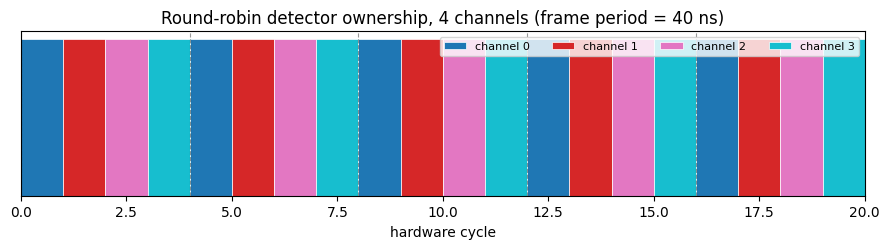

In [4]:
n_cycles_shown = 20
cycles = np.arange(n_cycles_shown)
active = np.array([tdm_active_channel(i, cfg["n_channels"]) for i in cycles])

fig, ax = plt.subplots(figsize=(9, 2.6))
colors = plt.cm.tab10(np.linspace(0, 1, cfg["n_channels"]))
for ch in range(cfg["n_channels"]):
    mask = active == ch
    ax.bar(cycles[mask], 1, width=1.0, color=colors[ch], align='edge',
           label=f"channel {ch}", edgecolor='white', linewidth=0.5)
ax.set_xlabel("hardware cycle")
ax.set_yticks([])
ax.set_title(f"Round-robin detector ownership, {cfg['n_channels']} channels "
             f"(frame period = {cfg['frame_period_s']*1e9:.0f} ns)")
ax.legend(loc='upper right', ncol=cfg["n_channels"], fontsize=8)
ax.set_xlim(0, n_cycles_shown)
for f in range(0, n_cycles_shown, cfg["n_channels"]):
    ax.axvline(f, color='black', lw=0.8, ls='--', alpha=0.4)
fig.tight_layout()
plt.show()

## 4. The tradeoff: more channels means less bandwidth per channel

$f_{channel} = f_{clk}/N$ is a hard tradeoff, not a design choice you can
optimize away -- adding a channel to the round robin divides everyone's
share of the clock. Swept here for a few representative detector clock
rates, including this repo's `dgs/adc.py`-scale ADC clocks.

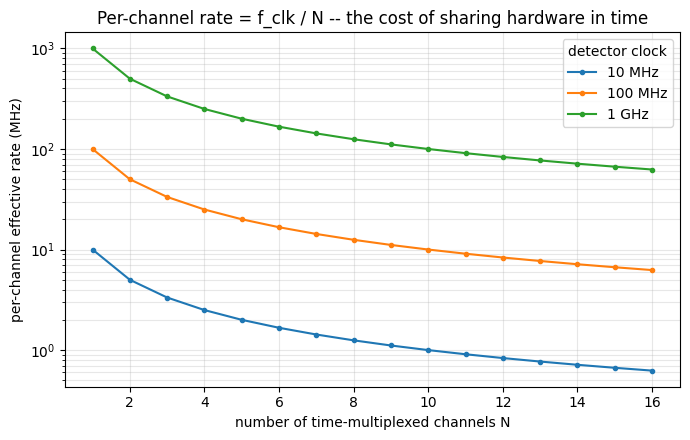

In [5]:
n_channels_range = np.arange(1, 17)
clk_rates_hz = {"10 MHz": 10e6, "100 MHz": 100e6, "1 GHz": 1e9}

fig, ax = plt.subplots(figsize=(7, 4.5))
for label, f_clk in clk_rates_hz.items():
    rates = [tdm_configure(f_clk, int(n))["per_channel_rate_hz"] for n in n_channels_range]
    ax.plot(n_channels_range, np.array(rates)/1e6, marker='o', ms=3, label=label)
ax.set_xlabel("number of time-multiplexed channels N")
ax.set_ylabel("per-channel effective rate (MHz)")
ax.set_yscale("log")
ax.set_title("Per-channel rate = f_clk / N -- the cost of sharing hardware in time")
ax.legend(title="detector clock")
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
plt.show()

## 5. Sanity checks

Same two checks `hardware/tdm_scheduler.c`'s `tdm_verify()` runs, repeated
here in Python: time-sharing splits the clock rather than losing any of
it, and every channel gets exactly one slot per frame.

In [6]:
for n in [1, 2, 3, 4, 7, 16]:
    cfg_n = tdm_configure(100e6, n)
    reconstructed = cfg_n["per_channel_rate_hz"] * n
    assert abs(reconstructed - 100e6) < 1e-6, f"failed for n={n}"

    counts = {}
    for i in range(n):
        ch = tdm_active_channel(i, n)
        counts[ch] = counts.get(ch, 0) + 1
    assert all(c == 1 for c in counts.values()), f"uneven schedule for n={n}"

print("[OK] per_channel_rate * N reconstructs f_clk for every N tested")
print("[OK] every channel appears exactly once per frame, for every N tested")

[OK] per_channel_rate * N reconstructs f_clk for every N tested
[OK] every channel appears exactly once per frame, for every N tested


## Summary

| Quantity | Formula | Where else it's implemented |
|---|---|---|
| Frame period | $N/f_{clk}$ | `hardware/tdm_scheduler.c` (`tdm_configure`) |
| Per-channel rate | $f_{clk}/N$ | `hardware/tdm_scheduler.c` (`tdm_configure`) |
| Round-robin schedule | $i \bmod N$ | `hardware/tdm_scheduler.v` (mod-N counter, RTL-simulated in `tdm_scheduler_tb.v`) |

Three independent implementations (this notebook, the C model, the
synthesizable Verilog) agree exactly -- the "both must agree" pattern this
repo's `hardware/` directory already uses for `fft8.c`/`fft8.v`, extended
to a third, Python-side check.